### Conceptual

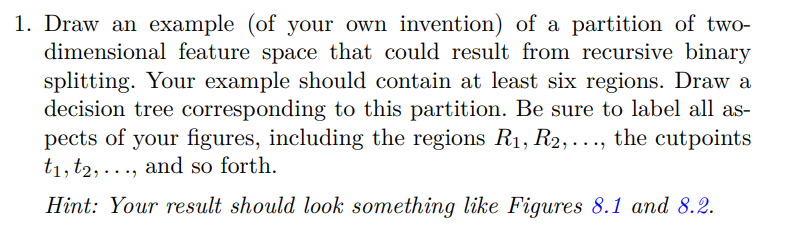

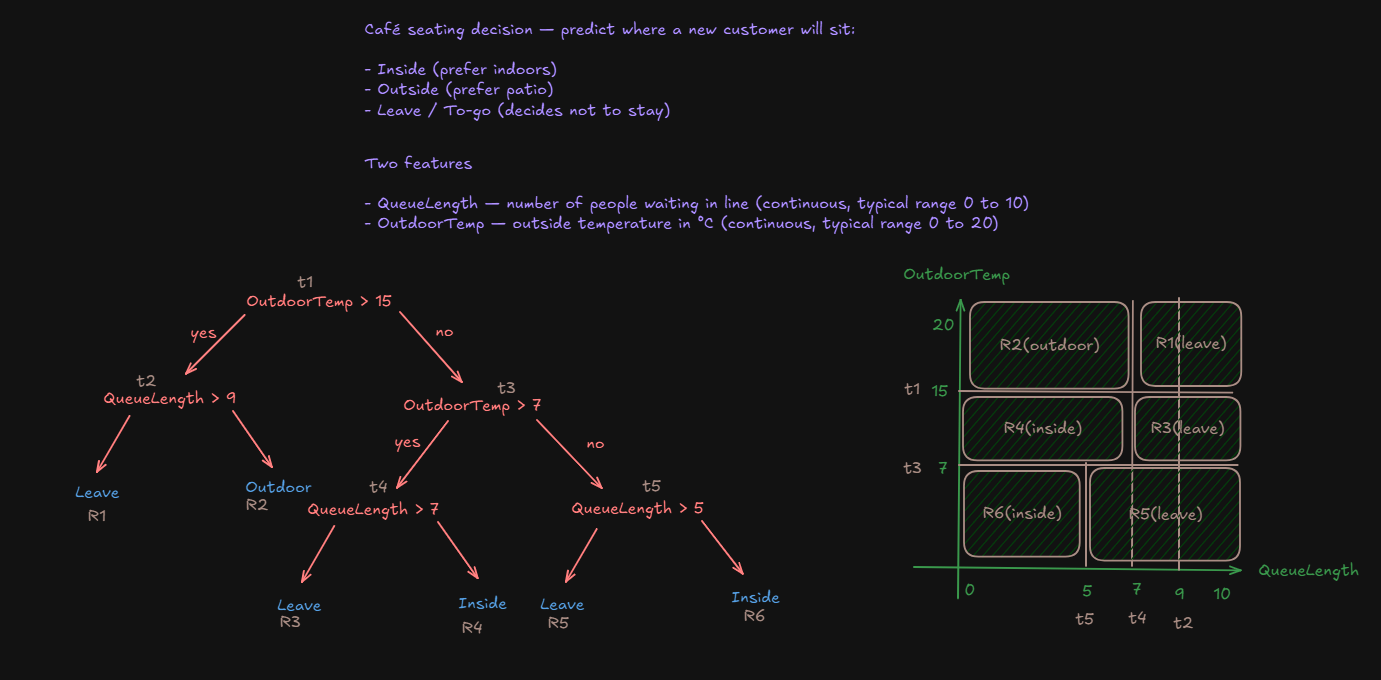

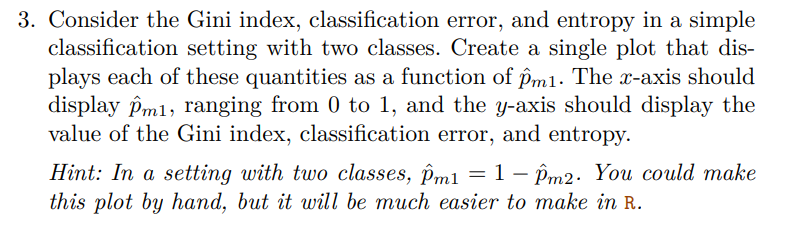

Gini index:
$$G_m = 1 - \sum_{k=1}^{K} \hat{p}_{mk}^2$$

Entropy:
$$D_m = -\sum_{k=1}^{K} \hat{p}_{mk} \log(\hat{p}_{mk})$$

Classification error:
$$E_m = 1 - \max_k (\hat{p}_{mk})$$

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
def gini_index(p_1):
  prop = np.array([p_1, 1 - p_1])
  return 1 - np.sum(prop**2)

def entropy(p_1):
  prop = np.array([p_1, 1 - p_1])
  return -np.sum([pi * np.log(pi) for pi in prop])

def classification_error(p_1):
  return 1 - max(p_1, 1 - p_1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13548\574197226.py:7: RuntimeWarning: divide by zero encountered in log
  return -np.sum([pi * np.log(pi) for pi in prop])
C:\Users\Admin\AppData\Local\Temp\ipykernel_13548\574197226.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  return -np.sum([pi * np.log(pi) for pi in prop])


[]

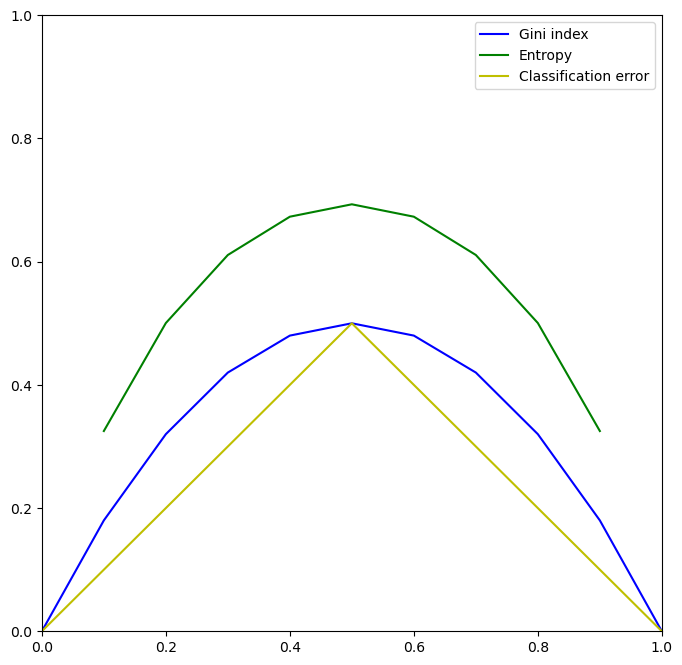

In [38]:
ax = plt.subplots(figsize=(8, 8))[1]

p_1 = np.linspace(0, 1, 11)
gini_values = [gini_index(pi) for pi in p_1]
entropy_values = [entropy(pi) for pi in p_1]
classification_error_values = [classification_error(pi) for pi in p_1]

ax.plot(p_1, gini_values, c="b", label="Gini index")
ax.plot(p_1, entropy_values, c="g", label="Entropy")
ax.plot(p_1, classification_error_values, c="y", label="Classification error")

ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.plot()

They all have an inverted U-shape, which makes sense because a node is most impure when the class proportion is 0.5, while it is pure when the proportion is 0 or 1.

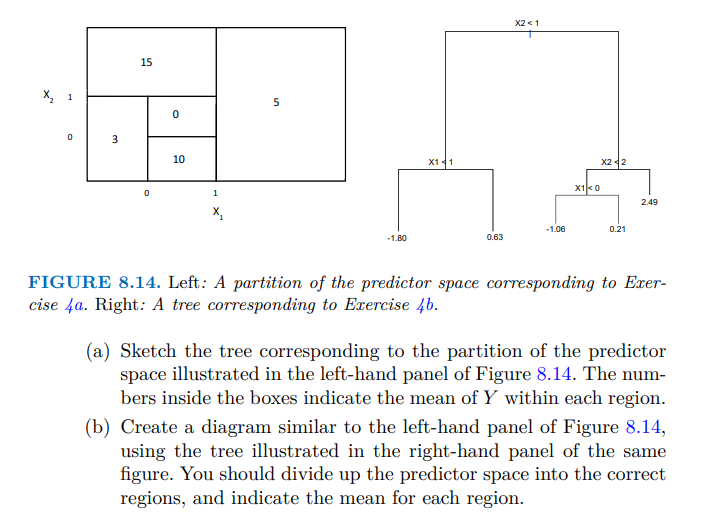

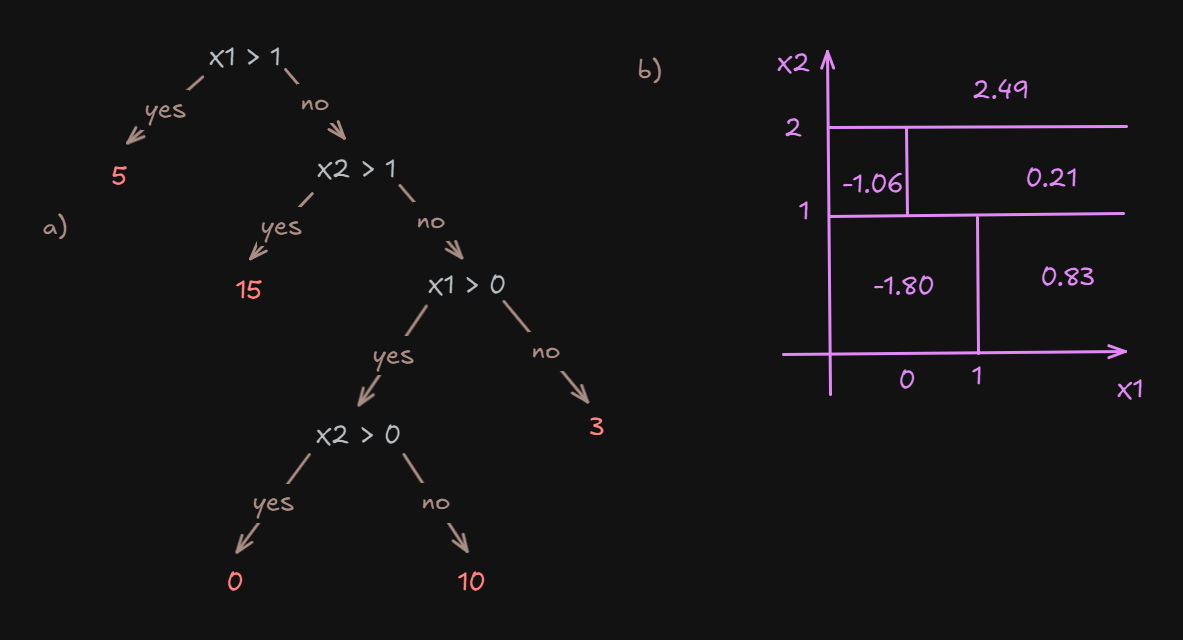

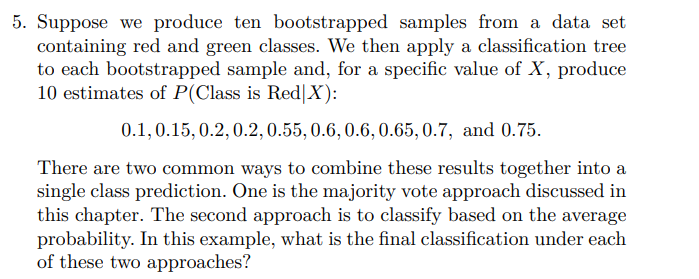

In [39]:
def majority_vote(decisions):
  vote_for_0 = (decisions < 0.5).sum()
  vote_for_1 = (decisions > 0.5).sum()
  
  return 0 if vote_for_0 > vote_for_1 else 1

In [40]:
def average_prob_classifier(decisions):
  return 0 if decisions.mean() < 0.5 else 0

In [41]:
decisions = np.array([0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, 0.75])

print("1. ", majority_vote(decisions))
print("2. ", average_prob_classifier(decisions))

1.  1
2.  0


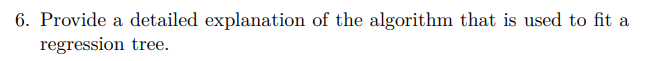

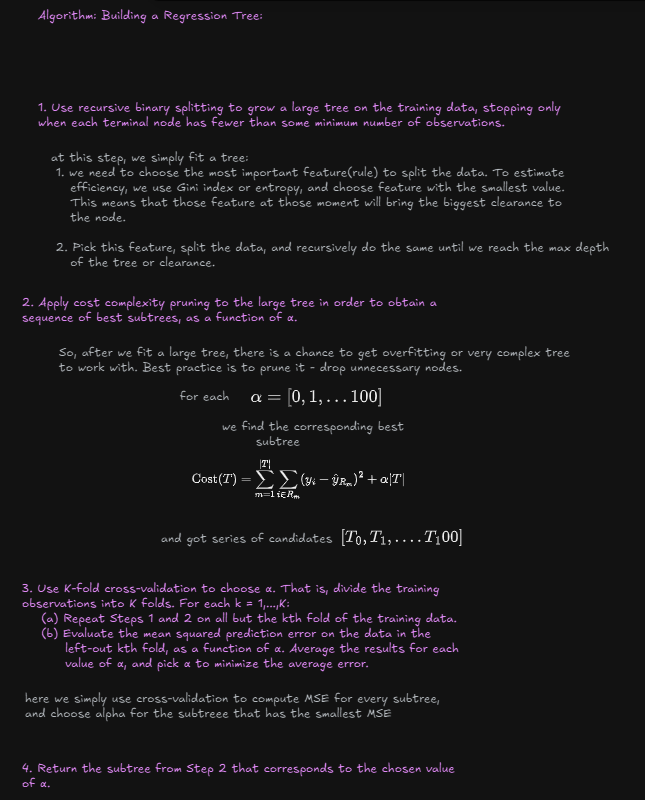

### Applied

In [42]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,
export_text)
from sklearn.metrics import (accuracy_score,
log_loss)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART

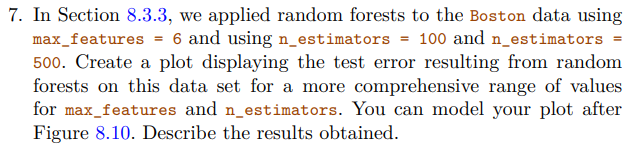

In [43]:
boston = load_data("Boston")
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [44]:
boston.shape

(506, 13)

In [45]:
X = boston.drop("medv", axis=1)
y = boston["medv"]

In [46]:
X_train, X_test, y_train, y_test = skm.train_test_split(X,
                                                        y,
                                                        test_size=0.3,
                                                        random_state=0)

So, for RandomForest we have to main hyperparameters:
- max_features - number of random features per tree
- n_estimators - number of trees in ensemble

In [47]:
RF_model = RF(random_state=0)

In [48]:
# K  = 5
# kfold = skm.KFold(n_splits=K,
#                   random_state=0,
#                   shuffle=True)

# # m - subset size of features(p) in a tree
# p = X_train.shape[1]

# param_grid = {
#   "n_estimators": np.linspace(0, 3000, 11).astype(int),
#   "max_features": [1, int(np.sqrt(p)), p // 2, p]  
# }

# grid = skm.GridSearchCV(estimator=RF_model,
#                         cv=kfold,
#                         param_grid=param_grid,
#                         scoring="neg_mean_squared_error")

# grid.fit(X, y)

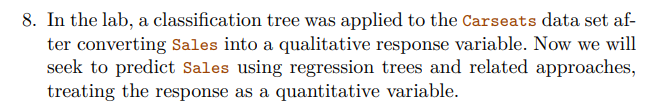

In [49]:
carseats = load_data("Carseats")
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


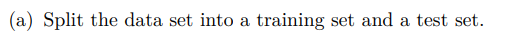

In [50]:
model = MS(carseats.drop("Sales", axis=1).columns, intercept=False)
D = model.fit_transform(carseats)
feature_names = list(D.columns)
X = np.asarray(D)
y = carseats["Sales"]

In [51]:
X_train, X_test, y_train, y_test = skm.train_test_split(X,
                                                        y, 
                                                        test_size=0.3, 
                                                        random_state=0)

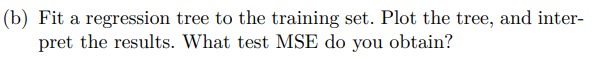

In [52]:
regr_tree_model = DTR(max_depth=3)
regr_tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [53]:
regr_tree_model.tree_.max_depth

3

[Text(0.5, 0.875, 'ShelveLoc[Good] <= 0.5\nsquared_error = 8.438\nsamples = 280\nvalue = 7.378'),
 Text(0.25, 0.625, 'ShelveLoc[Medium] <= 0.5\nsquared_error = 6.26\nsamples = 226\nvalue = 6.705'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Price <= 102.5\nsquared_error = 5.251\nsamples = 71\nvalue = 5.159'),
 Text(0.0625, 0.125, 'squared_error = 4.795\nsamples = 21\nvalue = 6.697'),
 Text(0.1875, 0.125, 'squared_error = 4.031\nsamples = 50\nvalue = 4.512'),
 Text(0.375, 0.375, 'Price <= 106.5\nsquared_error = 5.127\nsamples = 155\nvalue = 7.413'),
 Text(0.3125, 0.125, 'squared_error = 4.149\nsamples = 55\nvalue = 8.743'),
 Text(0.4375, 0.125, 'squared_error = 4.156\nsamples = 100\nvalue = 6.681'),
 Text(0.75, 0.625, 'Price <= 107.5\nsquared_error = 7.698\nsamples = 54\nvalue = 10.198'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Age <= 55.5\nsquared_error = 3.888\nsamples = 20\nvalue = 12.345'),
 Text(0.5625, 0.125, 'squared_error = 2.928\nsamples = 11\nvalue = 13.395

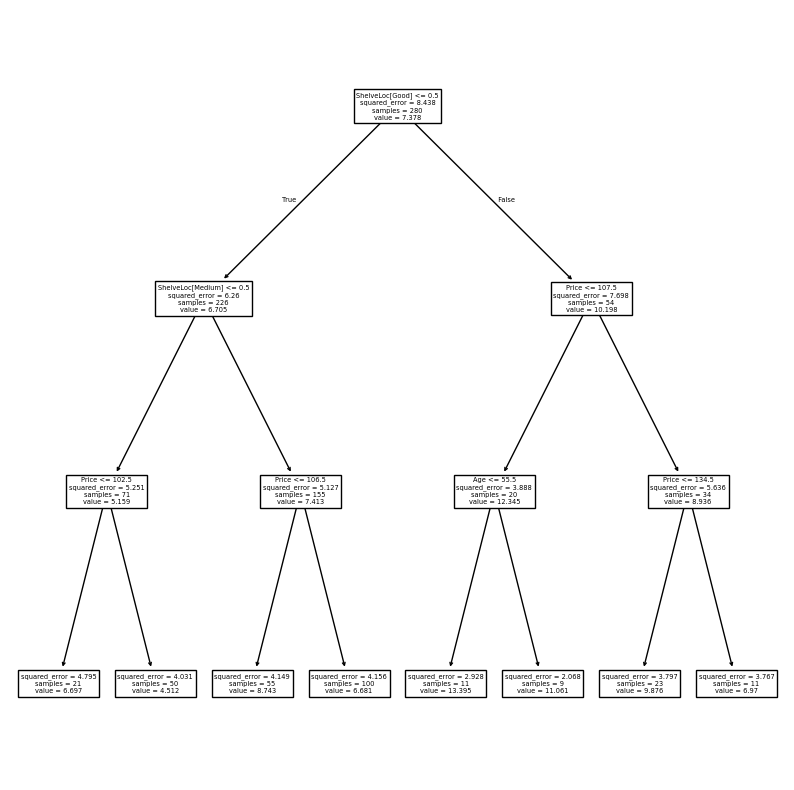

In [54]:
fig, ax = subplots(figsize=(10, 10))

plot_tree(ax=ax,
          decision_tree=regr_tree_model, 
          feature_names=feature_names)

In [55]:
y_pred = regr_tree_model.predict(X_test)

print("test MSE: ", np.mean((y_test - y_pred)**2))
print("test RMSE: ", np.sqrt(np.mean((y_test - y_pred)**2)))

test MSE:  3.7038582752360933
test RMSE:  1.924541055741886


So, from tree we see that `ShelveLoc` and `Price` are probably the most important features

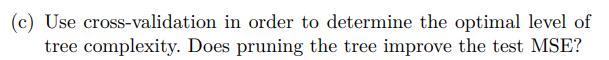

In [56]:
ccp_path = regr_tree_model.cost_complexity_pruning_path(X_train, y_train)
ccp_path

{'ccp_alphas': array([0.        , 0.09625833, 0.22444027, 0.25210042, 0.52253297,
        0.53848613, 0.88359258, 1.90014702]),
 'impurities': array([4.02025696, 4.1165153 , 4.34095557, 4.59305599, 5.11558896,
        5.65407509, 6.53766767, 8.43781468])}

In [57]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "ccp_alpha": ccp_path.ccp_alphas
}

grid = skm.GridSearchCV(estimator=regr_tree_model,
                        cv=kfold,
                        scoring="neg_mean_squared_error",
                        param_grid=param_grid)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=DecisionTreeRegressor(max_depth=3),
             param_grid={'ccp_alpha': array([0.        , 0.09625833, 0.22444027, 0.25210042, 0.52253297,
       0.53848613, 0.88359258, 1.90014702])},
             scoring='neg_mean_squared_error')

In [58]:
tuned_tree_model = grid.best_estimator_

In [59]:
tuned_tree_model.tree_.max_depth

3

In [60]:
y_pred = tuned_tree_model.predict(X_test)

print("test MSE: ", np.mean((y_test - y_pred)**2))
print("test RMSE: ", np.sqrt(np.mean((y_test - y_pred)**2)))

test MSE:  3.67145361913085
test RMSE:  1.9161037600116675


The error did not change, so pruning does not bring some improvements

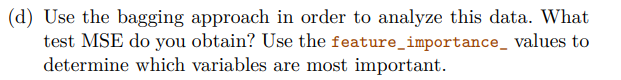

In [61]:
# as we remember: bagging is a special case of random forest, when p = m

bagging_model = RF(max_features=X_train.shape[1], n_estimators=500, random_state=0)
bagging_model.fit(X_train, y_train)

RandomForestRegressor(max_features=11, n_estimators=500, random_state=0)

In [62]:
y_pred = bagging_model.predict(X_test)

print("test MSE: ", np.mean((y_test - y_pred)**2))
print("test RMSE: ", np.sqrt(np.mean((y_test - y_pred)**2)))

test MSE:  2.0236328641333428
test RMSE:  1.4225445033928965


We see improvement of MSE: 3.703 ---> 2.02

In [63]:
feature_imp = pd.DataFrame({
  "importance": bagging_model.feature_importances_
}, index=feature_names)

feature_imp.sort_values(by="importance", ascending=False)

,importance
Price,0.286600
ShelveLoc[Good],0.220007
Age,0.105353
CompPrice,0.100679
ShelveLoc[Medium],0.085092
Advertising,0.068876
Income,0.053628
Population,0.039242
Education,0.029639
US[Yes],0.006542


As i said earlier, `Pirce` and `ShelveLoc` are the most important features

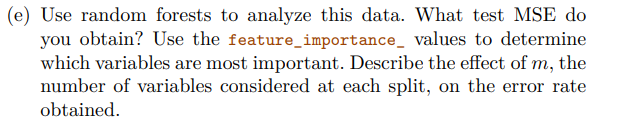

In [64]:
rand_forest_model = RF()

In [65]:
K = 5
kfold = skm.KFold(n_splits=K,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "max_features": np.linspace(1, X_train.shape[1], X_train.shape[1]).astype(int)
}

grid = skm.GridSearchCV(estimator=rand_forest_model,
                        param_grid=param_grid,
                        scoring="neg_mean_squared_error",
                        cv=kfold)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=RandomForestRegressor(),
             param_grid={'max_features': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])},
             scoring='neg_mean_squared_error')

In [66]:
grid.cv_results_["param_max_features"]

masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False],
       fill_value=999999)

In [67]:
grid.cv_results_["mean_test_score"]

array([-4.70551909, -3.8594357 , -3.35650721, -3.04266597, -3.073391  ,
       -2.8046677 , -2.85120843, -2.77577012, -2.76405798, -2.74162938,
       -2.81641012])

Text(0, 0.5, 'MSE')

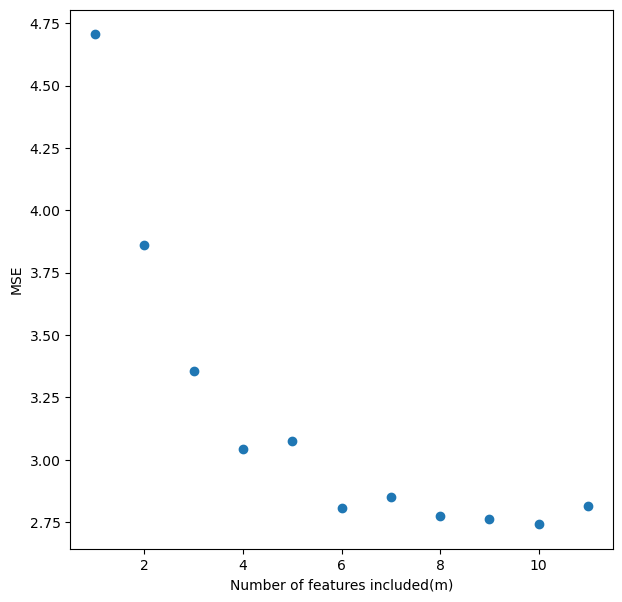

In [68]:
fig, ax = subplots(figsize=(7, 7))
ax.scatter(grid.cv_results_["param_max_features"],
           -grid.cv_results_["mean_test_score"])
ax.set_xlabel("Number of features included(m)")
ax.set_ylabel("MSE")

In [69]:
tuned_rand_for_model = grid.best_estimator_

In [70]:
y_pred = tuned_rand_for_model.predict(X_test)

print("test MSE: ", np.mean((y_test - y_pred)**2))
print("test RMSE: ", np.sqrt(np.mean((y_test - y_pred)**2)))

test MSE:  2.019011864666666
test RMSE:  1.420919373035172


Random forest has slightly better results than bagging model

In [71]:
feature_imp = pd.DataFrame(
  {"importance": tuned_rand_for_model.feature_importances_},
  index=feature_names
)
feature_imp.sort_values(by="importance", ascending=False)

,importance
Price,0.281406
ShelveLoc[Good],0.225668
CompPrice,0.100676
Age,0.099507
ShelveLoc[Medium],0.081929
Advertising,0.067296
Income,0.054923
Population,0.043408
Education,0.034149
US[Yes],0.006242


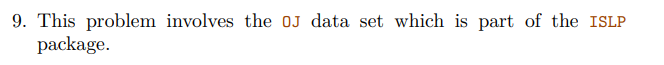

In [72]:
oj = load_data("OJ")
oj.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [73]:
oj.shape

(1070, 18)

In [74]:
oj.describe()

,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
count,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,254.381308,3.959813,1.867421,2.085411,0.051860,0.123364,0.147664,0.161682,0.565782,1.962047,1.815561,0.146486,0.059298,0.027314,0.217991,1.630841
std,15.558286,2.308984,0.101970,0.134386,0.117474,0.213834,0.354932,0.368331,0.307843,0.252697,0.143384,0.271563,0.101760,0.062232,0.107535,1.430387
min,227.000000,1.000000,1.690000,1.690000,0.000000,0.000000,0.000000,0.000000,0.000011,1.190000,1.390000,-0.670000,0.000000,0.000000,0.000000,0.000000
25%,240.000000,2.000000,1.790000,1.990000,0.000000,0.000000,0.000000,0.000000,0.325257,1.690000,1.750000,0.000000,0.000000,0.000000,0.140000,0.000000
50%,257.000000,3.000000,1.860000,2.090000,0.000000,0.000000,0.000000,0.000000,0.600000,2.090000,1.860000,0.230000,0.000000,0.000000,0.240000,2.000000
75%,268.000000,7.000000,1.990000,2.180000,0.000000,0.230000,0.000000,0.000000,0.850873,2.130000,1.890000,0.320000,0.112676,0.000000,0.300000,3.000000
max,278.000000,7.000000,2.090000,2.290000,0.500000,0.800000,1.000000,1.000000,0.999947,2.290000,2.090000,0.640000,0.402010,0.252688,0.440000,4.000000


In [75]:
oj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Purchase        1070 non-null   category
 1   WeekofPurchase  1070 non-null   int64   
 2   StoreID         1070 non-null   int64   
 3   PriceCH         1070 non-null   float64 
 4   PriceMM         1070 non-null   float64 
 5   DiscCH          1070 non-null   float64 
 6   DiscMM          1070 non-null   float64 
 7   SpecialCH       1070 non-null   int64   
 8   SpecialMM       1070 non-null   int64   
 9   LoyalCH         1070 non-null   float64 
 10  SalePriceMM     1070 non-null   float64 
 11  SalePriceCH     1070 non-null   float64 
 12  PriceDiff       1070 non-null   float64 
 13  Store7          1070 non-null   category
 14  PctDiscMM       1070 non-null   float64 
 15  PctDiscCH       1070 non-null   float64 
 16  ListPriceDiff   1070 non-null   float64 
 17  STORE         

In [76]:
oj["Purchase"].value_counts()

Purchase
CH    653
MM    417
Name: count, dtype: int64

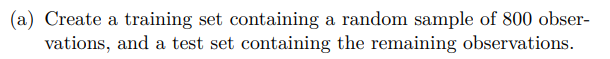

In [77]:
model = MS(oj.drop("Purchase", axis=1).columns, intercept=False)
D = model.fit_transform(oj)
X = np.asarray(D)
y = np.where(oj["Purchase"] == "CH", 1, 0)

feature_names = list(D.columns)

In [78]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, 
                                                        y, 
                                                        test_size= 1 - (800 * 100 / X.shape[0]) / 100, 
                                                        random_state=0)

In [79]:
X_train.shape

(799, 17)

Since `Purchase` is a categorical response, we will use classification decision tree

In [80]:
class_tree = DTC(random_state=0)
class_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [81]:
y_pred = class_tree.predict(X_train)
1 - accuracy_score(y_train, y_pred)

0.008760951188986232

Very small traning error rate

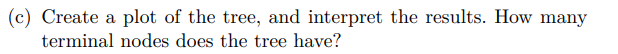

[Text(0.522198275862069, 0.96875, 'LoyalCH <= 0.509\ngini = 0.469\nsamples = 799\nvalue = [300.0, 499.0]'),
 Text(0.22198275862068967, 0.90625, 'LoyalCH <= 0.282\ngini = 0.413\nsamples = 340\nvalue = [241, 99]'),
 Text(0.3720905172413793, 0.9375, 'True  '),
 Text(0.07974137931034483, 0.84375, 'LoyalCH <= 0.062\ngini = 0.237\nsamples = 160\nvalue = [138, 22]'),
 Text(0.027586206896551724, 0.78125, 'StoreID <= 1.5\ngini = 0.064\nsamples = 60\nvalue = [58, 2]'),
 Text(0.013793103448275862, 0.71875, 'ListPriceDiff <= 0.15\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.006896551724137931, 0.65625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.020689655172413793, 0.65625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.041379310344827586, 0.71875, 'WeekofPurchase <= 268.5\ngini = 0.034\nsamples = 57\nvalue = [56, 1]'),
 Text(0.034482758620689655, 0.65625, 'gini = 0.0\nsamples = 49\nvalue = [49, 0]'),
 Text(0.04827586206896552, 0.65625, 'LoyalCH <= 0.001\ngini = 0.219\nsample

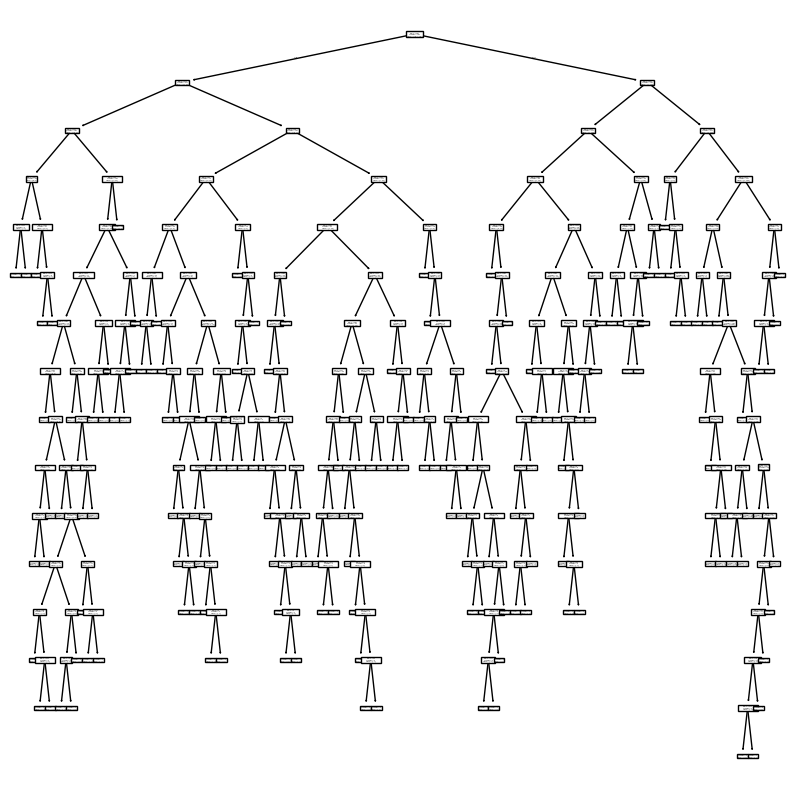

In [82]:
fig, ax = subplots(figsize=(10, 10))
plot_tree(
  ax=ax,
  feature_names=feature_names,
  decision_tree=class_tree
)

Wow.....a tiny number of terminal nodes in a tree

In [83]:
class_tree.get_n_leaves()

np.int64(161)

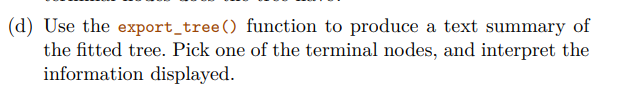

In [84]:
print(export_text(class_tree,
                  feature_names=feature_names,
                  show_weights=True))

|--- LoyalCH <= 0.51
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.06
|   |   |   |--- StoreID <= 1.50
|   |   |   |   |--- ListPriceDiff <= 0.15
|   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |--- ListPriceDiff >  0.15
|   |   |   |   |   |--- weights: [2.00, 0.00] class: 0
|   |   |   |--- StoreID >  1.50
|   |   |   |   |--- WeekofPurchase <= 268.50
|   |   |   |   |   |--- weights: [49.00, 0.00] class: 0
|   |   |   |   |--- WeekofPurchase >  268.50
|   |   |   |   |   |--- LoyalCH <= 0.00
|   |   |   |   |   |   |--- weights: [7.00, 0.00] class: 0
|   |   |   |   |   |--- LoyalCH >  0.00
|   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |--- LoyalCH >  0.06
|   |   |   |--- WeekofPurchase <= 273.50
|   |   |   |   |--- SalePriceCH <= 1.94
|   |   |   |   |   |--- WeekofPurchase <= 263.50
|   |   |   |   |   |   |--- STORE <= 1.50
|   |   |   |   |   |   |   |--- WeekofPurchase <= 228.00
|   |   |   |   |   |   |   |   |--- weights: [

In [92]:
oj["Purchase"]

0       CH
1       CH
2       CH
3       MM
4       CH
        ..
1065    CH
1066    CH
1067    MM
1068    CH
1069    CH
Name: Purchase, Length: 1070, dtype: category
Categories (2, object): ['CH', 'MM']

In [97]:
y_pred = class_tree.predict(X_test)

y_pred_label = np.where(y_pred == 1, "CH", "MM")
y_test_label = np.where(y_test == 1, "CH", "MM")


In [98]:
confusion_table(y_pred_label, y_test_label)

Truth,CH,MM
Predicted,,
CH,116,35
MM,38,82


From confusion matrix we see: class "CH" is truly predicted in 116 cases from 151, while class "MM" missclassified 82 times out of 140.

In [101]:
1 - accuracy_score(y_test, y_pred)

0.2693726937269373

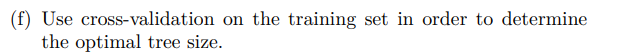

In [112]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "max_depth": np.linspace(1, 100, 100).astype(int)
}

grid = skm.GridSearchCV(class_tree,
                        param_grid,
                        scoring="accuracy",
                        refit=True,
                        cv=kfold)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])},
             scoring='accuracy')

In [115]:
tuned_class_tree = grid.best_estimator_
tuned_class_tree.get_depth()

4

In [117]:
grid.best_params_

{'max_depth': np.int64(4)}

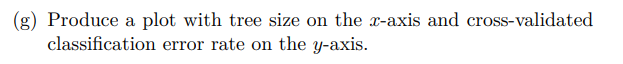

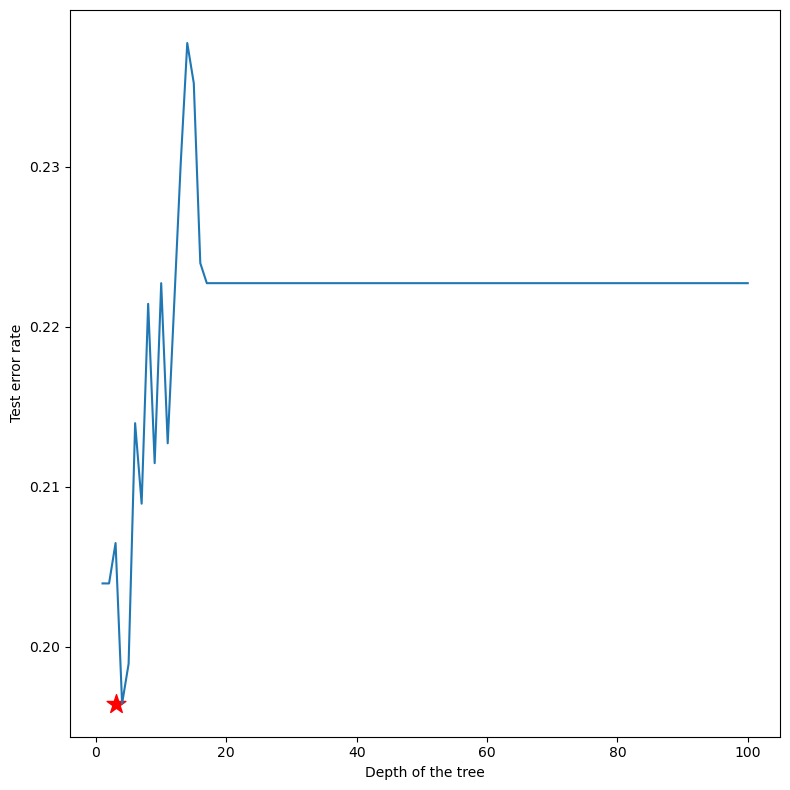

In [142]:
param_max_depth = grid.cv_results_["param_max_depth"].data
mean_test_score = 1 - grid.cv_results_["mean_test_score"]

fig, ax = subplots(figsize=(8, 8))
ax.plot(
  param_max_depth,
  mean_test_score
)
ax.set_xlabel("Depth of the tree")
ax.set_ylabel("Test error rate")

ax.scatter(np.argmin(mean_test_score), np.min(mean_test_score), marker='*', c='r', s=200)

plt.tight_layout()

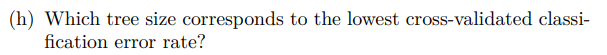

In [143]:
np.argmin(mean_test_score)

np.int64(3)

In [144]:
tuned_class_tree.get_n_leaves()

np.int64(16)

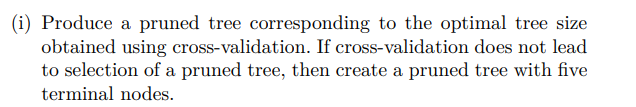

In [151]:
ccp_path = tuned_class_tree.cost_complexity_pruning_path(X_train, y_train)

kfold = skm.KFold(
  n_splits=5,
  random_state=0,
  shuffle=True
)

param_grid = {
  "ccp_alpha": ccp_path.ccp_alphas
}

grid = skm.GridSearchCV(estimator=tuned_class_tree,
                        param_grid=param_grid,
                        scoring="accuracy",
                        cv=kfold,
                        refit=True)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=DecisionTreeClassifier(max_depth=np.int64(4),
                                              random_state=0),
             param_grid={'ccp_alpha': array([0.        , 0.00068792, 0.00071142, 0.00105811, 0.00190715,
       0.00255975, 0.00260743, 0.00262829, 0.00468658, 0.00559247,
       0.01487592, 0.0160592 , 0.01786588, 0.16462966])},
             scoring='accuracy')

In [153]:
pruned_class_tree = grid.best_estimator_
pruned_class_tree.get_n_leaves()

np.int64(12)

In [154]:
pruned_class_tree.get_depth()

4

In [155]:
unpruned_error_rate = 1 - accuracy_score(y_train, tuned_class_tree.predict(X_train)) 
pruned_error_rate = 1 - accuracy_score(y_train, pruned_class_tree.predict(X_train))

print("Unpruned tree error rate: ", unpruned_error_rate) 
print("Pruned tree error rate: ", pruned_error_rate) 

Unpruned tree error rate:  0.15018773466833546
Pruned tree error rate:  0.15018773466833546


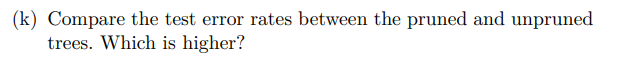

In [156]:
unpruned_test_error_rate = 1 - accuracy_score(y_test, tuned_class_tree.predict(X_test)) 
pruned_test_error_rate = 1 - accuracy_score(y_test, pruned_class_tree.predict(X_test))

print("Unpruned tree error rate: ", unpruned_test_error_rate) 
print("Pruned tree error rate: ", pruned_test_error_rate) 

Unpruned tree error rate:  0.22140221402214022
Pruned tree error rate:  0.21771217712177127


Pruned tree has slightly better results

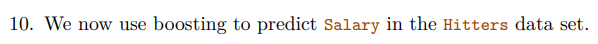

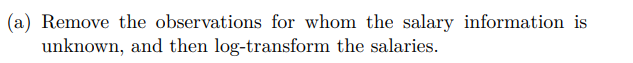

In [157]:
hitters = load_data("Hitters")
hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [158]:
hitters.shape

(322, 20)

In [159]:
hitters.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object')

In [160]:
hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

In [165]:
hitters = hitters.dropna()
hitters["Salary"] = np.log(hitters["Salary"])

hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,1.818615,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,1.820312,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,1.826903,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,1.507702,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,1.890106,A


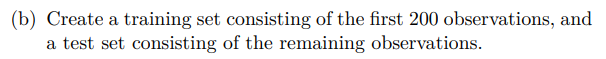

In [175]:
model = MS(hitters.columns.drop('Salary'), intercept=False)
D = model.fit_transform(hitters)
feature_names = list(D.columns)
X = np.asarray(D)
y = hitters['Salary']

X_train, y_train = X[:200], y[:200]
X_test, y_test = X[200:], y[200:]

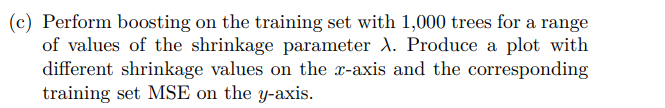

In [188]:
lambdas = np.linspace(0.0001, 0.1, 200)

train_MSE = np.zeros((len(lambdas)))
test_MSE = np.zeros((len(lambdas)))

for i, alpha in enumerate(lambdas):
  boosting = GBR(n_estimators=1000,
                 learning_rate=alpha,
                 max_depth=3,
                 random_state=0)
  
  boosting.fit(X_train, y_train)
  train_MSE[i] = np.mean((y_train - boosting.predict(X_train))**2)
  test_MSE[i] = np.mean((y_test - boosting.predict(X_test))**2)


In [193]:
np.argmin(test_MSE)

np.int64(7)

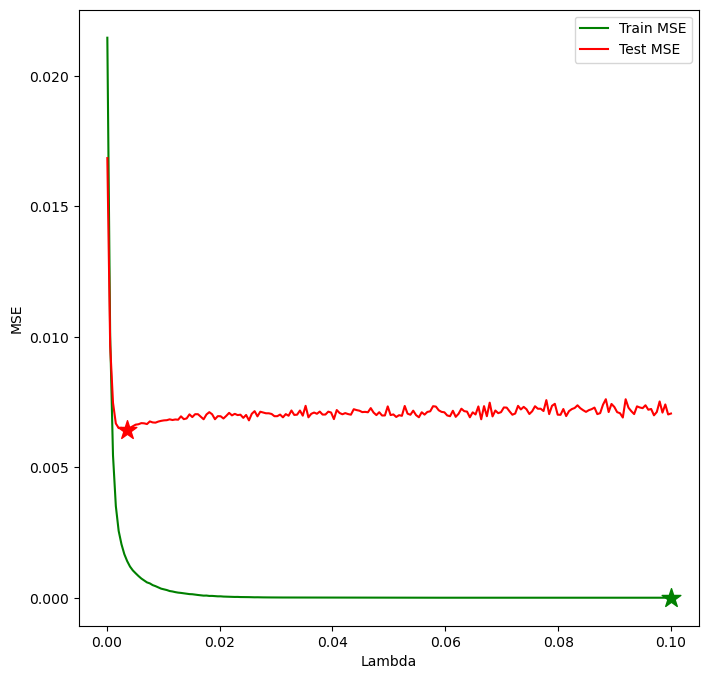

In [197]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(lambdas, train_MSE, c="g", label="Train MSE")
ax.scatter(lambdas[np.argmin(train_MSE)], np.min(train_MSE), marker="*", c="g", s=200)

ax.plot(lambdas, test_MSE, c="r", label="Test MSE")
ax.scatter(lambdas[np.argmin(test_MSE)], np.min(test_MSE), marker="*", c="r", s=200)

ax.set_xlabel("Lambda")
ax.set_ylabel("MSE")
ax.legend()
plt.show()

In [204]:
idx = np.argmin(test_MSE)
print(lambdas[idx])

boosting_test_MSE = np.min(test_MSE)
print(boosting_test_MSE)

0.003614070351758794
0.006441155412628111


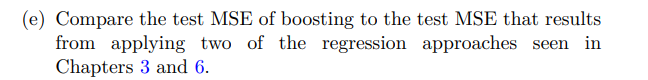

In [211]:
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [210]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_test_MSE = np.mean((y_test - lin_reg.predict(X_test))**2)
lin_reg_test_MSE

np.float64(0.014969962169318432)

In [214]:
scaler = StandardScaler(
  with_mean=True,
  with_std=True
)

kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

lassoCV = ElasticNetCV(l1_ratio=1,
                     cv=kfold,
                     max_iter=2000)

pipeCV = Pipeline([
  ("scaler", scaler),
  ("lasso", lassoCV)
])

pipeCV.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 ElasticNetCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
                              l1_ratio=1, max_iter=2000))])

In [219]:
lassoCV.alpha_

np.float64(0.006562978523552122)

In [220]:
lassoCV.coef_

array([ 0.        ,  0.05179965,  0.        ,  0.00023485,  0.        ,
        0.01407956,  0.05379301,  0.        ,  0.        ,  0.00587112,
        0.02101328,  0.        ,  0.        ,  0.0017355 , -0.00672411,
        0.01353352,  0.        , -0.        ,  0.        ])

In [222]:
lasso_test_MSE = np.mean((y_test - pipeCV.predict(X_test))**2)
lasso_test_MSE

np.float64(0.014023441295391247)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13548\1690929973.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mse_values, palette="viridis")


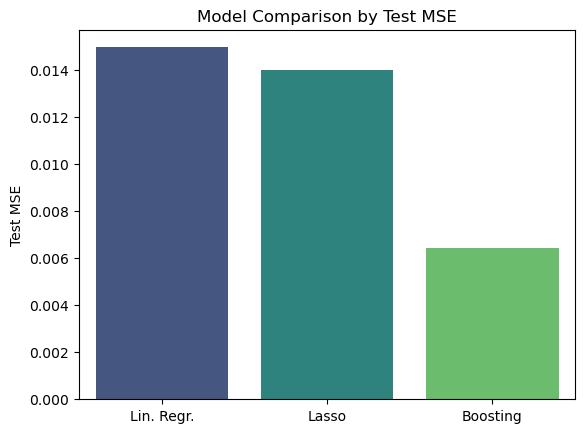

In [227]:
import seaborn as sns

mse_values = [lin_reg_test_MSE, lasso_test_MSE, boosting_test_MSE]
models = ["Lin. Regr.", "Lasso", "Boosting"]

sns.barplot(x=models, y=mse_values, palette="viridis")


plt.ylabel("Test MSE")
plt.title("Model Comparison by Test MSE")
plt.show()

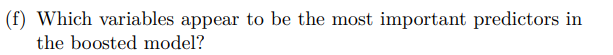

In [229]:
feature_imp = pd.DataFrame({
  "importance": boosting.feature_importances_
}, index=feature_names)

feature_imp.sort_values(by="importance", ascending=False)

,importance
CAtBat,0.559436
CHits,0.095087
CRuns,0.047875
Walks,0.045256
AtBat,0.039902
CRBI,0.039117
Hits,0.033510
Years,0.028920
CHmRun,0.028445
CWalks,0.028102


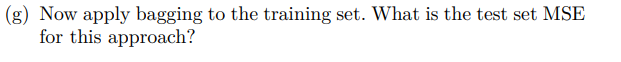

In [230]:
bagging_tree = RF(max_features=X_train.shape[1], 
                  n_estimators=1000,
                  random_state=0)

bagging_tree.fit(X_train, y_train)
np.mean((y_test - bagging_tree.predict(X_test))**2)

np.float64(0.0071358189801321555)

Almost the same as in boosting model

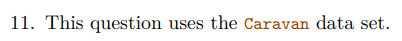

In [232]:
caravan = load_data("Caravan")
caravan.head()

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,Purchase
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,1,0,0,0,0,0,No
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,1,0,0,0,0,0,No
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,1,0,0,0,0,0,No
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,1,0,0,0,0,0,No


In [233]:
caravan.columns

Index(['MOSTYPE', 'MAANTHUI', 'MGEMOMV', 'MGEMLEEF', 'MOSHOOFD', 'MGODRK',
       'MGODPR', 'MGODOV', 'MGODGE', 'MRELGE', 'MRELSA', 'MRELOV', 'MFALLEEN',
       'MFGEKIND', 'MFWEKIND', 'MOPLHOOG', 'MOPLMIDD', 'MOPLLAAG', 'MBERHOOG',
       'MBERZELF', 'MBERBOER', 'MBERMIDD', 'MBERARBG', 'MBERARBO', 'MSKA',
       'MSKB1', 'MSKB2', 'MSKC', 'MSKD', 'MHHUUR', 'MHKOOP', 'MAUT1', 'MAUT2',
       'MAUT0', 'MZFONDS', 'MZPART', 'MINKM30', 'MINK3045', 'MINK4575',
       'MINK7512', 'MINK123M', 'MINKGEM', 'MKOOPKLA', 'PWAPART', 'PWABEDR',
       'PWALAND', 'PPERSAUT', 'PBESAUT', 'PMOTSCO', 'PVRAAUT', 'PAANHANG',
       'PTRACTOR', 'PWERKT', 'PBROM', 'PLEVEN', 'PPERSONG', 'PGEZONG',
       'PWAOREG', 'PBRAND', 'PZEILPL', 'PPLEZIER', 'PFIETS', 'PINBOED',
       'PBYSTAND', 'AWAPART', 'AWABEDR', 'AWALAND', 'APERSAUT', 'ABESAUT',
       'AMOTSCO', 'AVRAAUT', 'AAANHANG', 'ATRACTOR', 'AWERKT', 'ABROM',
       'ALEVEN', 'APERSONG', 'AGEZONG', 'AWAOREG', 'ABRAND', 'AZEILPL',
       'APLEZIER', 'AFIETS',

In [234]:
caravan.shape

(5822, 86)

In [248]:
caravan["Purchase"].value_counts()

Purchase
No     5474
Yes     348
Name: count, dtype: int64

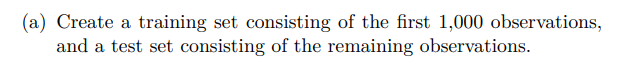

In [250]:
model = MS(caravan.drop("Purchase", axis=1).columns, intercept=False)
design = model.fit_transform(caravan)
feature_names = list(design.columns)
X = np.asarray(design)
y = np.where(caravan["Purchase"] == "Yes", 1, 0)

In [263]:
X_train, X_test = X[0:1000], X[1000:]
y_train, y_test = y[0:1000], y[1000:]

In [253]:
y_test.shape

(4822,)

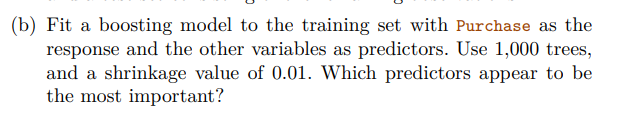

In [259]:
from sklearn.ensemble import GradientBoostingClassifier as GBC

boosting_tree = GBC(
  n_estimators=1000,
  learning_rate=0.01,
  random_state=0
)

boosting_tree.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, n_estimators=1000,
                           random_state=0)

In [260]:
feature_imp = pd.DataFrame({
  "importance": boosting_tree.feature_importances_
}, index=feature_names)

feature_imp.sort_values(by="importance", ascending=False)

,importance
PPERSAUT,0.074593
MOSTYPE,0.067117
ABRAND,0.056449
MGODGE,0.052966
MKOOPKLA,0.047597
...,...
PBROM,0.000000
APERSONG,0.000000
ABROM,0.000000
AWERKT,0.000000


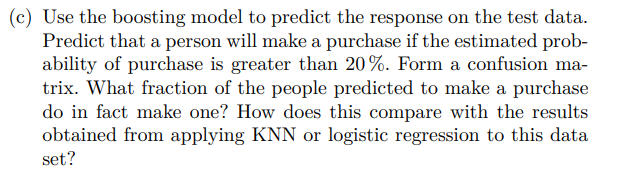

In [265]:
y_proba = boosting_tree.predict_proba(X_test)
y_proba

array([[0.97420521, 0.02579479],
       [0.95516316, 0.04483684],
       [0.984695  , 0.015305  ],
       ...,
       [0.95235931, 0.04764069],
       [0.89500081, 0.10499919],
       [0.97384333, 0.02615667]])

In [283]:
y_pred_label = np.where(y_proba[:, 1] > 0.2, "Yes", "No")
y_pred = np.where(y_proba[:, 1] > 0.2, 1, 0)
y_test_label = np.where(y_test == 1, "Yes", "No")

confusion_table(y_pred_label, y_test_label)

Truth,No,Yes
Predicted,,
No,4335,251
Yes,198,38


In [285]:
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer

print("f1-score: ", f1_score(y_test, y_pred))
print("recall: ", recall_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred))
print("accuracy: ", accuracy_score(y_test, y_pred))

f1-score:  0.14476190476190476
recall:  0.1314878892733564
precision:  0.16101694915254236
accuracy:  0.9068851099128992


In [281]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [286]:
knn = KNeighborsClassifier()

kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "n_neighbors": range(1, 100)
}

custom_scorer = make_scorer(precision_score, pos_label="Yes", zero_division=0)

grid = skm.GridSearchCV(knn,
                        param_grid=param_grid,
                        cv=kfold,
                        scoring=custom_scorer).fit(X_train, y_train)

d:\Documents\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\Documents\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "d:\Documents\anaconda\Lib\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Documents\anaconda\Lib\site-packages\sklearn\metrics\_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "d:\Documents\anaconda\Lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get

In [287]:
grid.best_params_

{'n_neighbors': 1}

In [288]:
best_knn = grid.best_estimator_

print("f1-score: ", f1_score(y_test, y_pred))
print("recall: ", recall_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred))
print("accuracy: ", accuracy_score(y_test, y_pred))

f1-score:  0.14476190476190476
recall:  0.1314878892733564
precision:  0.16101694915254236
accuracy:  0.9068851099128992
